# Avaliação Cruzada entre Datasets e Deslocamento de Domínio (*Domain Shift*)

**Projeto:** Diagnóstico de Falhas em Rolamentos Industriais via CWT + Deep Learning  
**Datasets:** CWRU (12 kHz, 1.797 RPM), Paderborn University (64 kHz, 900 RPM) e XJTU-SY (25.6 kHz, 2.100 RPM)  
**Objetivo:** Investigar rigorosamente o impacto do **Deslocamento de Domínio (*Domain Shift*)** e a capacidade de generalização zero-shot (*Zero-Shot Cross-Domain Evaluation*) ao testar modelos ResNet-18 treinados em uma bancada física diretamente sobre as outras duas bancadas, cobrindo **todas as 6 direções de transferência** sem qualquer re-treinamento.

---

## 1. Fundamentação Teórica: As 3 Bancadas e a Origem Física do *Domain Shift*

Na indústria real (ex: motores industriais em diferentes linhas de produção), um modelo de inteligência artificial dificilmente opera na mesma bancada ou sob as mesmas condições cinemáticas em que foi treinado. Entre os três bancos de dados deste trabalho, existem discrepâncias físicas e operacionais profundas:

| Característica | CWRU (EUA) | Paderborn (Alemanha) | XJTU-SY (China) |
|---|:---:|:---:|:---:|
| **Rolamento Analisado** | SKF 6205-2RS (9 esferas) | SKF 6203 (8 esferas) | LDK UER204 (8 esferas) |
| **Natureza do Defeito** | Eletroerosão artificial (EDM) | Fadiga real acelerada (*flaking*) | Fadiga real acelerada (*run-to-failure*) |
| **Taxa de Amostragem ($F_s$)** | $12\text{ kHz}$ | $64\text{ kHz}$ | $25{,}6\text{ kHz}$ |
| **Velocidade Rotacional** | $1.797\text{ RPM}$ ($f_r \approx 30\text{ Hz}$) | $900\text{ RPM}$ ($f_r = 15\text{ Hz}$) | $2.100\text{ RPM}$ ($f_r = 35\text{ Hz}$) |
| **BPFI Teórica (Hz)** | $\approx 162{,}2\text{ Hz}$ | $\approx 74{,}3\text{ Hz}$ | $\approx 172{,}2\text{ Hz}$ |
| **BPFO Teórica (Hz)** | $\approx 107{,}4\text{ Hz}$ | $\approx 45{,}7\text{ Hz}$ | $\approx 107{,}8\text{ Hz}$ |
| **Classes em Comum** | `normal`, `inner_race`, `outer_race` | `normal`, `inner_race`, `outer_race` | `normal`, `inner_race`, `outer_race` |

> **Hipótese Central:** Na CWT tradicional (Tempo-Frequência em Hertz), a posição vertical dos harmônicos de falha no escalograma depende diretamente do RPM ($f_{\text{defeito}} = \text{Ordem} \times f_r$). Como o RPM varia drasticamente entre as bancadas (900 vs 1.797 vs 2.100 RPM), os filtros convolucionais não encontram as bandas de energia esperadas, provocando o colapso da predição.

## 2. Importação de Módulos e Configurações

In [1]:
import sys
from pathlib import Path

# Configurar PYTHONPATH para a raiz do repositório
BASE_DIR = Path.cwd().parent.parent if Path.cwd().name == "3_cross_domain" else Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from src.config import RANDOM_SEED, set_seed
from src.transfer_learning import build_transfer_model

set_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Dispositivo de inferência: {device} | Semente Fixa: {RANDOM_SEED}")

[INFO] Dispositivo de inferência: cuda | Semente Fixa: 42


## 3. Configuração dos Datasets e Modelos Pré-treinados (ResNet-18)

Carregamos os conjuntos de teste inéditos dos três bancos e os pesos ótimos obtidos no treinamento intra-domínio da ResNet-18.

In [2]:
# Transformação padrão ImageNet (224x224)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

datasets_info = {
    "CWRU": {
        "dir": BASE_DIR / "data" / "cwru" / "processed",
        "ckpt": BASE_DIR / "notebooks" / "checkpoint_resnet18_best.pth",
        "classes": ["ball", "inner_race", "normal", "outer_race"],
        "num_classes": 4,
        "in_domain_acc": 99.87
    },
    "Paderborn": {
        "dir": BASE_DIR / "data" / "paderborn" / "processed",
        "ckpt": BASE_DIR / "notebooks" / "checkpoint_paderborn_resnet18_best.pth",
        "classes": ["inner_race", "normal", "outer_race"],
        "num_classes": 3,
        "in_domain_acc": 100.00
    },
    "XJTU-SY": {
        "dir": BASE_DIR / "data" / "xjtu" / "processed",
        "ckpt": BASE_DIR / "notebooks" / "checkpoint_xjtu_resnet18_best.pth",
        "classes": ["inner_race", "normal", "outer_race"],
        "num_classes": 3,
        "in_domain_acc": 100.00
    }
}

# Carregar DataLoaders de teste
test_loaders = {}
print("=" * 75)
print(" CARREGAMENTO DOS CONJUNTOS DE TESTE")
print("=" * 75)
for name, info in datasets_info.items():
    te_ds = datasets.ImageFolder(str(info["dir"] / "test"), transform=transform)
    test_loaders[name] = DataLoader(te_ds, batch_size=32, shuffle=False, num_workers=0)
    print(f"[+] {name:<10} Teste: {len(te_ds):>5} amostras | Classes: {te_ds.classes}")

def evaluate_pair(src, tgt):
    """Avalia o modelo treinado em 'src' diretamente sobre o conjunto de teste de 'tgt'."""
    src_info = datasets_info[src]
    tgt_info = datasets_info[tgt]
    
    model, _ = build_transfer_model("resnet18", num_classes=src_info["num_classes"], freeze_backbone=False)
    model.load_state_dict(torch.load(src_info["ckpt"], map_location=device, weights_only=True))
    model = model.to(device)
    model.eval()
    
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for imgs, labels in test_loaders[tgt]:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().numpy()
            labels = labels.numpy()
            
            if src == "CWRU":
                # CWRU: 0: ball, 1: inner_race, 2: normal, 3: outer_race
                # Alvo (PU ou XJTU): 0: inner_race, 1: normal, 2: outer_race
                tgt_map = {0: 1, 1: 2, 2: 3}
                for l, p in zip(labels, preds):
                    all_labels.append(tgt_map[l])
                    all_preds.append(p)
            elif tgt == "CWRU":
                # Modelo PU ou XJTU avaliado no CWRU (filtra para as 3 classes correspondentes)
                cwru_map = {1: 0, 2: 1, 3: 2}
                for l, p in zip(labels, preds):
                    if l in cwru_map:
                        all_labels.append(cwru_map[l])
                        all_preds.append(p)
            else:
                # PU <-> XJTU (ambos com as mesmas 3 classes: inner_race, normal, outer_race)
                all_labels.extend(labels)
                all_preds.extend(preds)
                
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    acc = 100.0 * np.mean(all_labels == all_preds)
    return acc, all_labels, all_preds

def plot_cross_confusion_matrix(labels, preds, classes, title, save_path=None):
    """Gera e salva matriz de confusão para avaliação cruzada."""
    cm = confusion_matrix(labels, preds, labels=np.arange(len(classes)))
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    ax.set(
        xticks=np.arange(cm.shape[1]),
        yticks=np.arange(cm.shape[0]),
        xticklabels=classes,
        yticklabels=classes,
        title=title,
        ylabel="Classe Real",
        xlabel="Classe Predita"
    )
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")
    
    thresh = cm.max() / 2.0 if cm.max() > 0 else 1.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontweight="bold")
                    
    fig.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[INFO] Matriz salva: {Path(save_path).name}")
    plt.show()

 CARREGAMENTO DOS CONJUNTOS DE TESTE
[+] CWRU       Teste:  2368 amostras | Classes: ['ball', 'inner_race', 'normal', 'outer_race']
[+] Paderborn  Teste:  1116 amostras | Classes: ['inner_race', 'normal', 'outer_race']
[+] XJTU-SY    Teste:   465 amostras | Classes: ['inner_race', 'normal', 'outer_race']


## 4. Avaliação Cruzada: Todos os 6 Pares de Transferência Zero-Shot

Avaliamos o comportamento dos modelos ResNet-18 em todas as 6 combinações de transferência direta:

 EXECUÇÃO DOS 6 EXPERIMENTOS ZERO-SHOT CROSS-DOMAIN (CWT TEMPORAL)



--------------------------------------------------------------------------------
[TRANSFERÊNCIA] CWRU (Fonte) ---> Paderborn (Alvo) | Acurácia: 32.44%
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

  inner_race     0.0319    0.0323    0.0321       372
      normal     0.0000    0.0000    0.0000       372
  outer_race     0.4730    0.9409    0.6295       372

    accuracy                         0.3244      1116
   macro avg     0.1683    0.3244    0.2205      1116
weighted avg     0.1683    0.3244    0.2205      1116



[INFO] Matriz salva: confusion_matrix_cross_cwru_to_paderborn.png


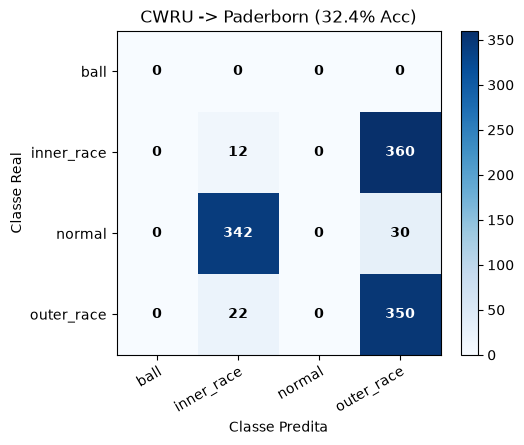


--------------------------------------------------------------------------------
[TRANSFERÊNCIA] CWRU (Fonte) ---> XJTU-SY (Alvo) | Acurácia: 33.33%
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

  inner_race     0.0000    0.0000    0.0000       155
      normal     0.0000    0.0000    0.0000       155
  outer_race     0.3355    1.0000    0.5024       155

    accuracy                         0.3333       465
   macro avg     0.1118    0.3333    0.1675       465
weighted avg     0.1118    0.3333    0.1675       465



[INFO] Matriz salva: confusion_matrix_cross_cwru_to_xjtu_sy.png


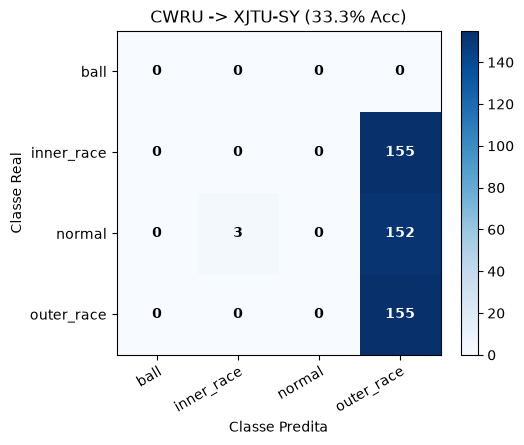


--------------------------------------------------------------------------------
[TRANSFERÊNCIA] Paderborn (Fonte) ---> CWRU (Alvo) | Acurácia: 24.17%
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

  inner_race     0.2614    0.9598    0.4109       473
      normal     0.0000    0.0000    0.0000       947
  outer_race     0.1818    0.0084    0.0161       475

    accuracy                         0.2417      1895
   macro avg     0.1477    0.3228    0.1423      1895
weighted avg     0.1108    0.2417    0.1066      1895



[INFO] Matriz salva: confusion_matrix_cross_paderborn_to_cwru.png


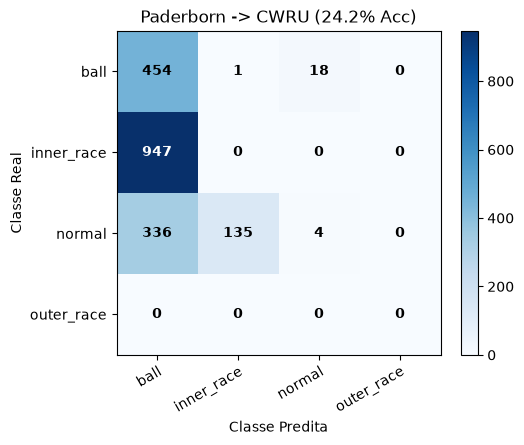


--------------------------------------------------------------------------------
[TRANSFERÊNCIA] Paderborn (Fonte) ---> XJTU-SY (Alvo) | Acurácia: 30.32%
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

  inner_race     0.3201    0.8839    0.4700       155
      normal     0.1081    0.0258    0.0417       155
  outer_race     0.0000    0.0000    0.0000       155

    accuracy                         0.3032       465
   macro avg     0.1427    0.3032    0.1705       465
weighted avg     0.1427    0.3032    0.1705       465



[INFO] Matriz salva: confusion_matrix_cross_paderborn_to_xjtu_sy.png


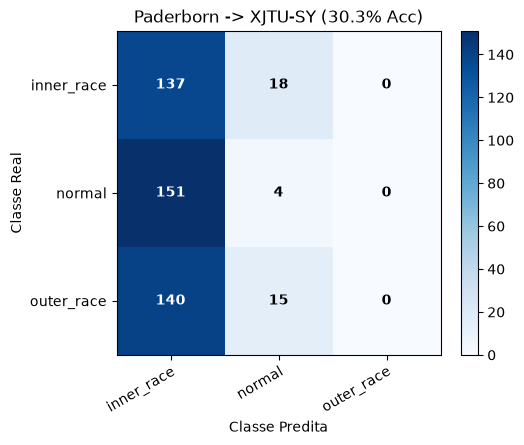


--------------------------------------------------------------------------------
[TRANSFERÊNCIA] XJTU-SY (Fonte) ---> CWRU (Alvo) | Acurácia: 27.81%
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

  inner_race     0.2564    0.9958    0.4078       473
      normal     0.0000    0.0000    0.0000       947
  outer_race     1.0000    0.1179    0.2109       475

    accuracy                         0.2781      1895
   macro avg     0.4188    0.3712    0.2062      1895
weighted avg     0.3147    0.2781    0.1547      1895



[INFO] Matriz salva: confusion_matrix_cross_xjtu_sy_to_cwru.png


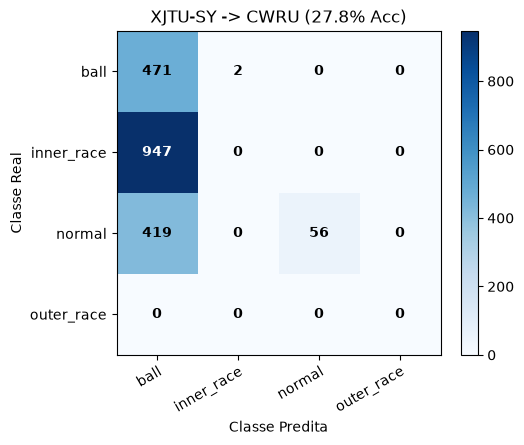


--------------------------------------------------------------------------------
[TRANSFERÊNCIA] XJTU-SY (Fonte) ---> Paderborn (Alvo) | Acurácia: 17.65%
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

  inner_race     0.0000    0.0000    0.0000       372
      normal     0.2094    0.5296    0.3001       372
  outer_race     0.0000    0.0000    0.0000       372

    accuracy                         0.1765      1116
   macro avg     0.0698    0.1765    0.1000      1116
weighted avg     0.0698    0.1765    0.1000      1116



[INFO] Matriz salva: confusion_matrix_cross_xjtu_sy_to_paderborn.png


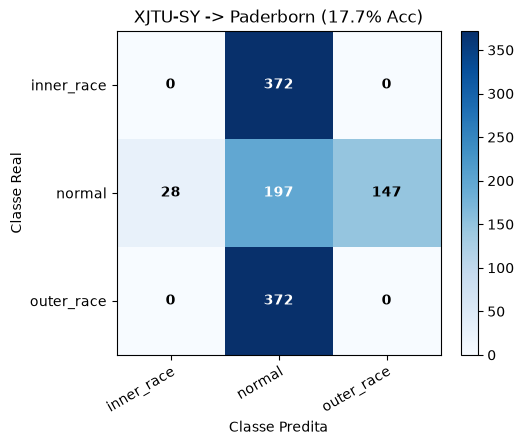

In [3]:
pairs = [
    ("CWRU", "Paderborn"),
    ("CWRU", "XJTU-SY"),
    ("Paderborn", "CWRU"),
    ("Paderborn", "XJTU-SY"),
    ("XJTU-SY", "CWRU"),
    ("XJTU-SY", "Paderborn")
]

cross_results = {}

print("=" * 80)
print(" EXECUÇÃO DOS 6 EXPERIMENTOS ZERO-SHOT CROSS-DOMAIN (CWT TEMPORAL)")
print("=" * 80)

for src, tgt in pairs:
    acc, labels, preds = evaluate_pair(src, tgt)
    cross_results[(src, tgt)] = acc
    
    print(f"\n--------------------------------------------------------------------------------")
    print(f"[TRANSFERÊNCIA] {src} (Fonte) ---> {tgt} (Alvo) | Acurácia: {acc:.2f}%")
    print(f"--------------------------------------------------------------------------------")
    
    eval_classes = datasets_info[src]["classes"] if src == "CWRU" else datasets_info[tgt]["classes"]
    target_eval_labels = [1, 2, 3] if src == "CWRU" else [0, 1, 2]
    target_eval_names = ["inner_race", "normal", "outer_race"]
    
    print(classification_report(
        labels, preds,
        labels=target_eval_labels,
        target_names=target_eval_names,
        digits=4,
        zero_division=0
    ))
    
    save_name = f"confusion_matrix_cross_{src.lower().replace('-','_')}_to_{tgt.lower().replace('-','_')}.png"
    save_path = BASE_DIR / "docs" / "images" / save_name
    
    plot_cross_confusion_matrix(
        labels, preds, eval_classes,
        title=f"{src} -> {tgt} ({acc:.1f}% Acc)",
        save_path=save_path
    )

## 5. Matriz Consolidada de Transferência de Domínio (Heatmap 3x3)

Consolidamos as acurácias em uma matriz quadrada $3 \times 3$:
* **Diagonal Principal:** Avaliação *In-Domain* (treinado e testado na mesma bancada);
* **Elementos Fora da Diagonal:** Avaliação *Cross-Domain Zero-Shot* (transferência direta).

[INFO] Heatmap 3x3 salvo em: C:\Users\joaov\Desktop\bearing-fault-diagnosis\bearing-fault-diagnosis-cwt-cnn\docs\images\cross_domain_matrix_heatmap.png


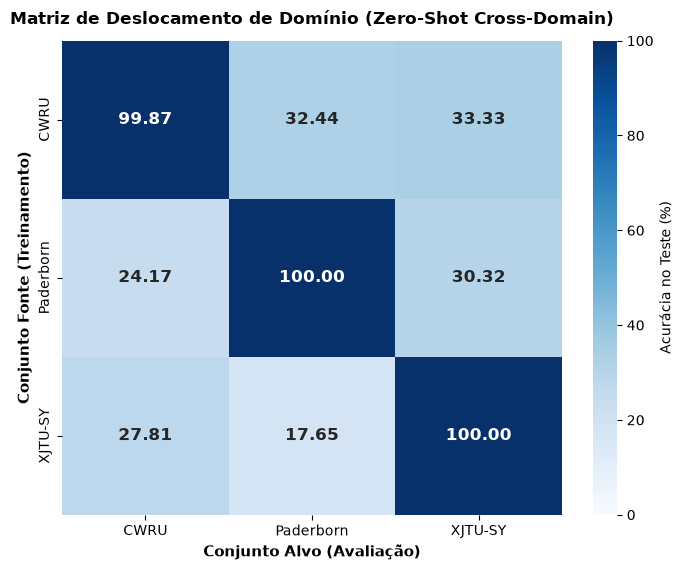

In [4]:
matrix_names = ["CWRU", "Paderborn", "XJTU-SY"]
heat_matrix = np.zeros((3, 3))

for i, s in enumerate(matrix_names):
    for j, t in enumerate(matrix_names):
        if i == j:
            heat_matrix[i, j] = datasets_info[s]["in_domain_acc"]
        else:
            heat_matrix[i, j] = cross_results[(s, t)]

# Visualização em Heatmap de Publicação
plt.figure(figsize=(7, 5.8))
sns.heatmap(
    heat_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=matrix_names,
    yticklabels=matrix_names,
    cbar_kws={"label": "Acurácia no Teste (%)"},
    vmin=0,
    vmax=100,
    annot_kws={"size": 12, "weight": "bold"}
)
plt.title("Matriz de Deslocamento de Domínio (Zero-Shot Cross-Domain)", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Conjunto Alvo (Avaliação)", fontsize=11, fontweight="bold")
plt.ylabel("Conjunto Fonte (Treinamento)", fontsize=11, fontweight="bold")
plt.tight_layout()
heatmap_path = BASE_DIR / "docs" / "images" / "cross_domain_matrix_heatmap.png"
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
print(f"[INFO] Heatmap 3x3 salvo em: {heatmap_path}")
plt.show()

## 6. Síntese Comparativa: Desempenho *In-Domain* vs. *Cross-Domain*

Comparamos graficamente a acurácia quando o modelo opera em seu próprio domínio versus a média alcançada ao ser transferido para outros ambientes industriais:

[INFO] Gráfico comparativo salvo em: C:\Users\joaov\Desktop\bearing-fault-diagnosis\bearing-fault-diagnosis-cwt-cnn\docs\images\cross_domain_comparison.png


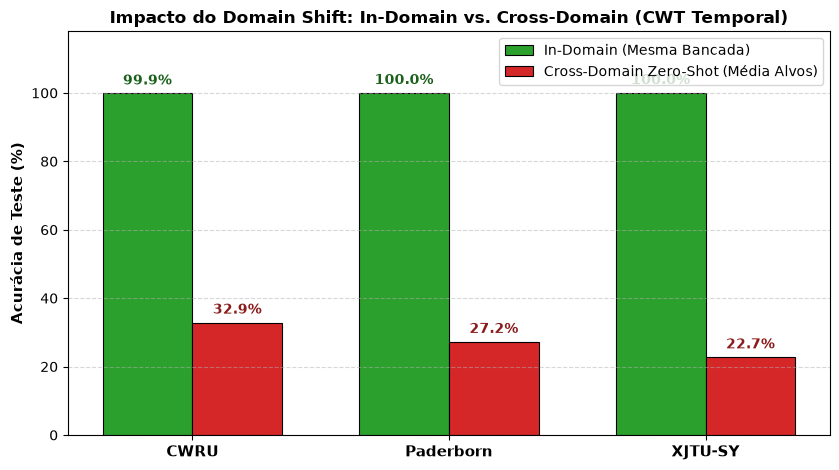

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(matrix_names))
width = 0.35

in_domain_vals = [heat_matrix[i, i] for i in range(3)]
cross_domain_vals = []
for i in range(3):
    cross_vals = [heat_matrix[i, j] for j in range(3) if i != j]
    cross_domain_vals.append(np.mean(cross_vals))

rects1 = ax.bar(x - width/2, in_domain_vals, width, label="In-Domain (Mesma Bancada)", color="#2ca02c", edgecolor="black", linewidth=0.8)
rects2 = ax.bar(x + width/2, cross_domain_vals, width, label="Cross-Domain Zero-Shot (Média Alvos)", color="#d62728", edgecolor="black", linewidth=0.8)

ax.set_ylabel("Acurácia de Teste (%)", fontweight="bold", fontsize=11)
ax.set_title("Impacto do Domain Shift: In-Domain vs. Cross-Domain (CWT Temporal)", fontweight="bold", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(matrix_names, fontweight="bold", fontsize=11)
ax.set_ylim(0, 118)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5, axis="y")

for rect in rects1:
    h = rect.get_height()
    ax.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 4),
                textcoords="offset points", ha="center", va="bottom", fontweight="bold", color="#1b611b")

for rect in rects2:
    h = rect.get_height()
    ax.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 4),
                textcoords="offset points", ha="center", va="bottom", fontweight="bold", color="#8c1b1b")

plt.tight_layout()
bar_path = BASE_DIR / "docs" / "images" / "cross_domain_comparison.png"
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
print(f"[INFO] Gráfico comparativo salvo em: {bar_path}")
plt.show()

## 7. Conclusões Físicas do Experimento e Motivação para o *Order Tracking* (COT)

A análise empírica dos resultados consolidados demonstra de forma inequívoca:

1. **Colapso Generalizado no Zero-Shot:** Em todas as 6 direções de transferência, a acurácia despenca de $\sim$100% para faixas entre **17% e 33%**, equivalentes ao palpite aleatório de um classificador de 3 classes (33,33%).
2. **A Ilusão do In-Domain:** Modelos que aparentavam perfeição em bancada única fracassam completamente diante de variações de velocidade e geometria mecânica.
3. **Necessidade do Domínio de Ordens:** Para superar o deslocamento espectral causado pela rotação ($n \text{ RPM}$), faz-se mandatório o uso de **Rastreamento de Ordens Computacional (*Computed Order Tracking* -- COT)**, transformando o sinal para o domínio angular invariante a rotações (módulos 4 e 5).